In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("food_delivery_orders.csv")
df

,order_date,city,restaurant_category,cuisine,order_value,discount_percent,delivery_time_min,rating,profit_per_order
0,2023-01-01,Karachi,Fine Dining,Continental,2768.0,25.0,36.2,4.5,95.0
1,2023-01-01,Karachi,Fine Dining,Steakhouse,4979.0,44.8,23.3,4.8,-437.0
2,2023-01-01,Karachi,Cloud Kitchen,Indian,4008.0,11.9,39.6,4.2,618.0
3,2023-01-01,Islamabad,Fine Dining,Steakhouse,3260.0,8.3,35.8,4.5,423.0
4,2023-01-01,Karachi,Fast Food,Pizza,435.0,13.5,29.4,4.8,53.0
...,...,...,...,...,...,...,...,...,...
4195,2024-06-30,Islamabad,Dessert,Cakes,447.0,5.2,45.6,3.8,46.0
4196,2024-06-30,Karachi,Fast Food,Sandwiches,455.0,15.4,25.1,5.0,-11.0
4197,2024-06-30,Multan,Cloud Kitchen,Biryani,826.0,15.1,23.0,5.0,136.0
4198,2024-06-30,Lahore,Cafe,Bakery,428.0,12.5,38.1,4.4,-20.0


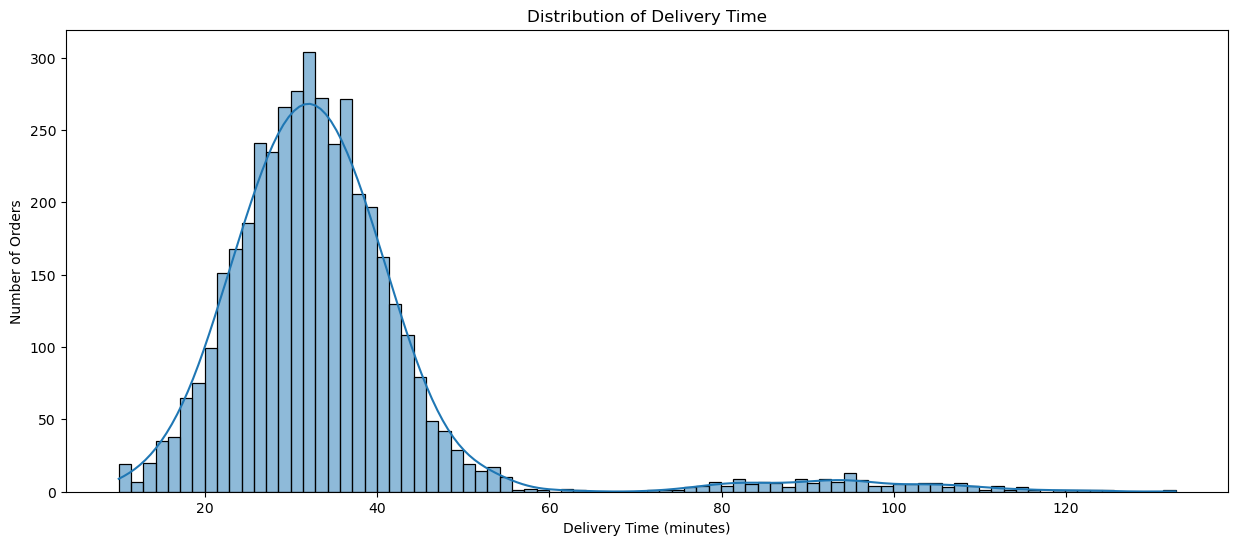

Skewness: 2.8770611473024483
Mean: 34.541809523809526
Median: 32.5


In [6]:
# Task 1 
#The delivery time is right skewed
#The median of 32.5 minutes is more honest than the mean of 34.54 minutes because the mean is affected by outliers but median isnt that much affected with outliers it shows mean

plt.figure(figsize=(15, 6))
sns.histplot(df["delivery_time_min"], kde=True)
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Number of Orders")
plt.title("Distribution of Delivery Time")
plt.show()

print("Skewness:", df["delivery_time_min"].skew())
print("Mean:", df["delivery_time_min"].mean())
print("Median:", df["delivery_time_min"].median())

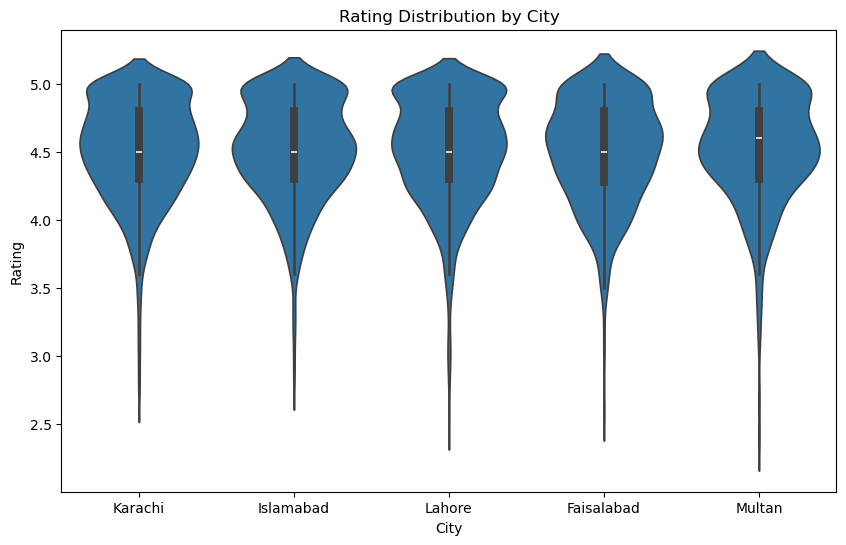

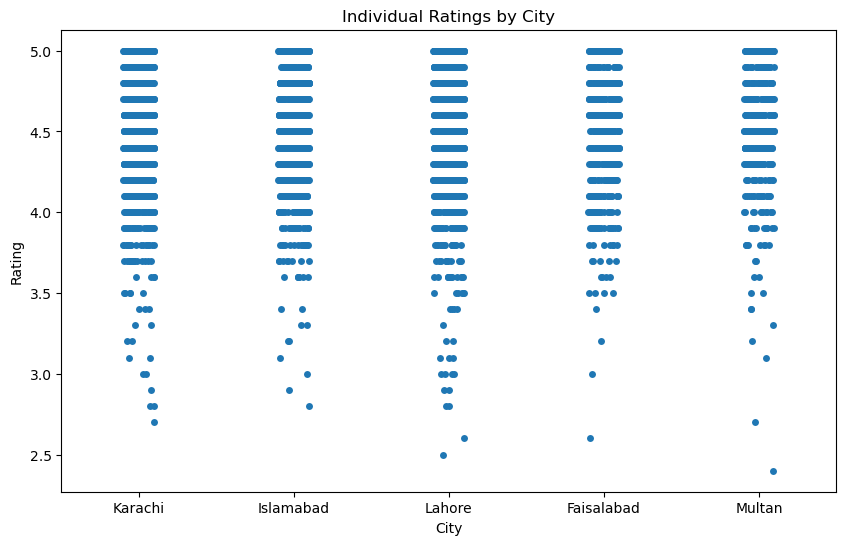

In [7]:
# Task 2 Answer: Multan shows the most inconsistent customer experience because it has the widest rating spread, with the highest standard deviation among the cities.

plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x="city", y="rating")
plt.xlabel("City")
plt.ylabel("Rating")
plt.title("Rating Distribution by City")
plt.show()

plt.figure(figsize=(10, 6))
sns.stripplot(data=df, x="city", y="rating", jitter=True)
plt.xlabel("City")
plt.ylabel("Rating")
plt.title("Individual Ratings by City")
plt.show()


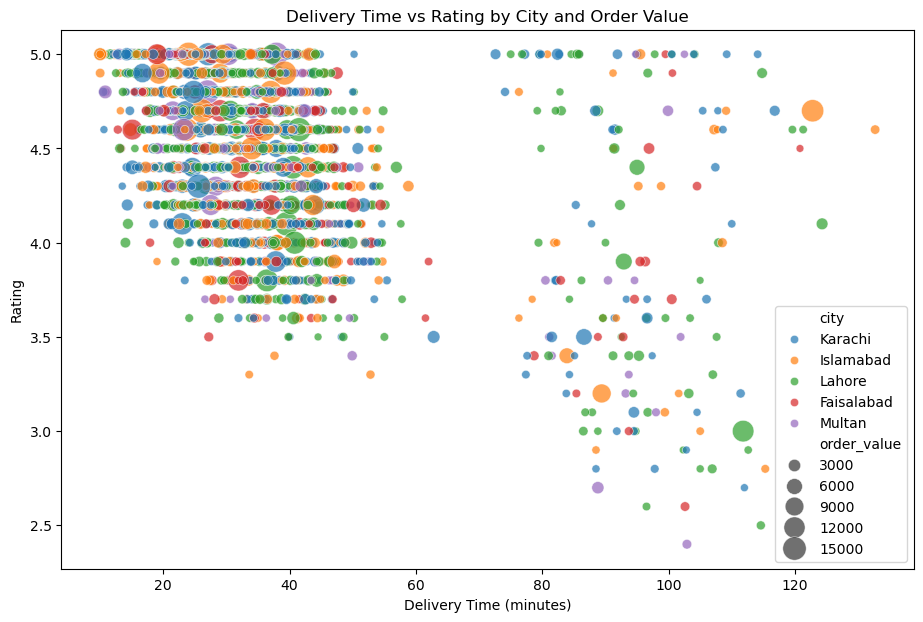

             order_value  delivery_time_min    rating
value_group                                          
Low           407.740371          35.093438  4.508203
Medium        758.913448          34.243634  4.507010
High         2279.035186          34.287143  4.511643


In [8]:
# Task # 3

plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=df,
    x="delivery_time_min",
    y="rating",
    hue="city",
    size="order_value",
    sizes=(30, 300),
    alpha=0.7
)
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Rating")
plt.title("Delivery Time vs Rating by City and Order Value")
plt.show()

value_groups = pd.qcut(
    df["order_value"],
    3,
    labels=["Low", "Medium", "High"]
)

print(
    df.assign(value_group=value_groups)
    .groupby("value_group", observed=False)[
        ["order_value", "delivery_time_min", "rating"]
    ]
    .mean()
)
#High-value orders show a slight tendency toward faster delivery and higher ratings, but the difference is too small to indicate a strong relationship

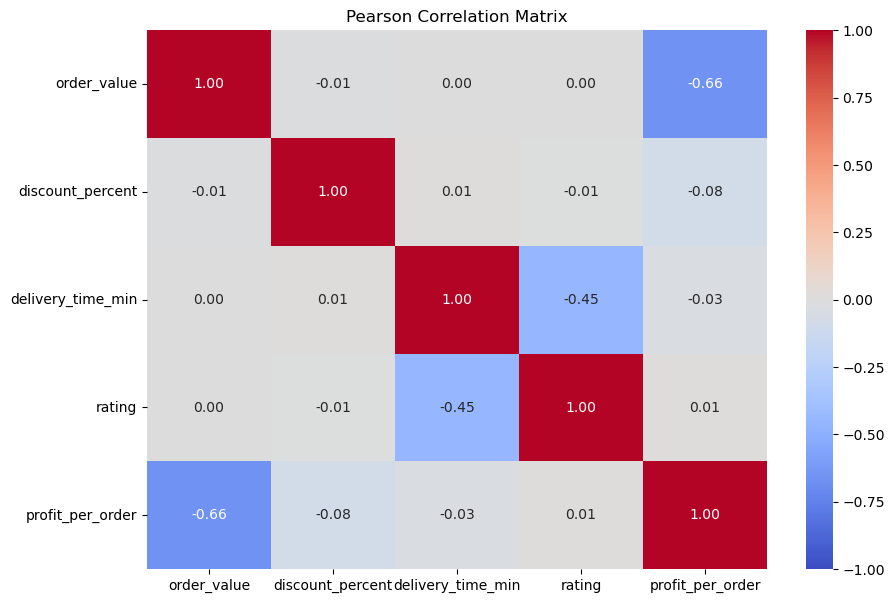

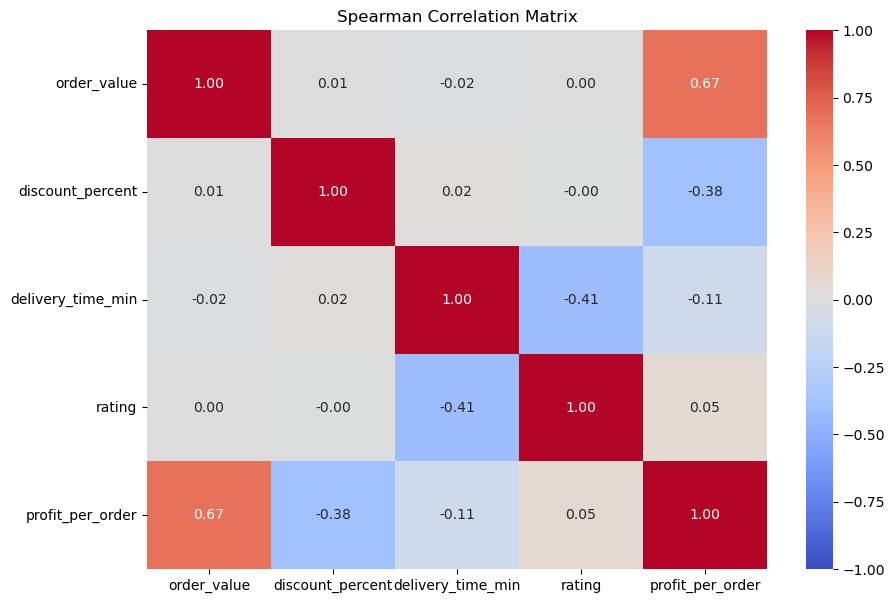

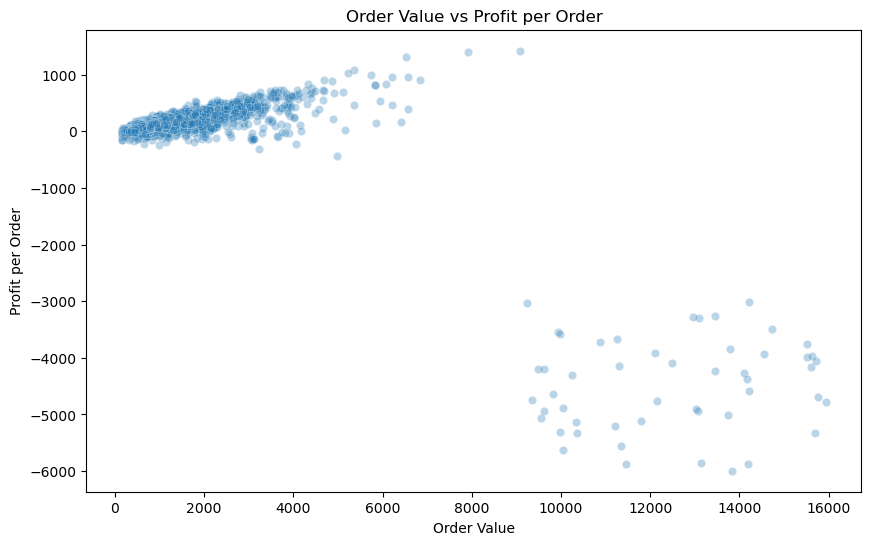

In [10]:

# Task 4 Answer: The largest Pearson-Spearman disagreement occurs between order_value and profit_per_order. Pearson is -0.657 while Spearman is 0.673, and the disagreement is mainly caused by a small number of extreme high-value orders. Valid extreme orders should not automatically be dropped; they should be retained unless they are data errors, while Spearman can be reported as the more robust measure. Correlation does not imply causation.

numeric_cols = [
    "order_value",
    "discount_percent",
    "delivery_time_min",
    "rating",
    "profit_per_order"
]

pearson_corr = df[numeric_cols].corr(method="pearson")
spearman_corr = df[numeric_cols].corr(method="spearman")

plt.figure(figsize=(10, 7))
sns.heatmap(
    pearson_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0
)
plt.title("Pearson Correlation Matrix")
plt.show()

plt.figure(figsize=(10, 7))
sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0
)
plt.title("Spearman Correlation Matrix")
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="order_value",
    y="profit_per_order",
    alpha=0.3
)
plt.xlabel("Order Value")
plt.ylabel("Profit per Order")
plt.title("Order Value vs Profit per Order")
plt.show()

# Pearson and Spearman disagree most for order_value and profit_per_order.
# The scatter plot shows that a small number of extreme high-value orders affect the Pearson correlation.
# The disagreement is therefore mainly caused by extreme orders rather than a genuinely non-linear trend.
# These extreme orders should not be removed automatically because they may be valid real orders.
# They should only be removed if they are confirmed to be errors or invalid observations.
# For management reporting, Spearman can be reported because it is less affected by extreme values.
# Correlation does not imply causation; a correlation between two variables does not prove that one causes the other.


restaurant_category       Cafe  Cloud Kitchen    Dessert  Fast Food  \
city                                                                  
Faisalabad           67.295455      65.779748 -70.312281  20.222750   
Islamabad           -13.499649      57.011427 -27.884178  37.177258   
Karachi             -38.901838     136.745480  75.240260  15.375665   
Lahore               52.345680     137.614221  65.515000  10.618693   
Multan               60.137931     -82.783323  55.865385 -40.784432   
All                  14.648580      91.829915  31.277856  13.613870   

restaurant_category  Fine Dining        All  
city                                         
Faisalabad            293.695652  51.891636  
Islamabad             153.117851  35.491634  
Karachi               302.801418  74.101668  
Lahore                159.818290  71.552572  
Multan                285.181818  12.622372  
All                   228.922310  57.370067  


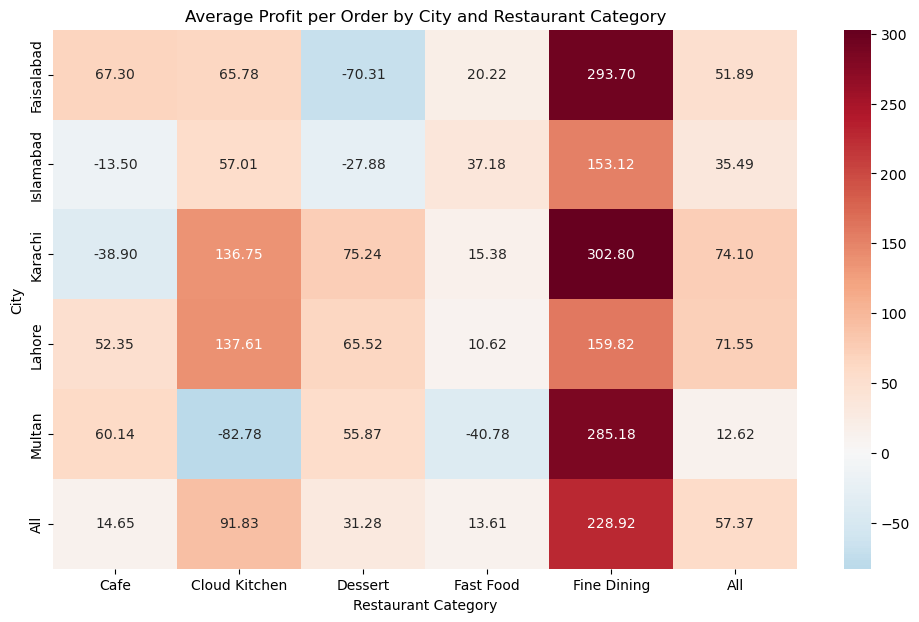

In [11]:
# Task 5 Answer: Karachi and Fine Dining is the most profitable combination, with an average profit per order of about 302.80. It is not the top revenue generator; Lahore and Cloud Kitchen generates the highest total revenue, showing that high revenue and high profitability are different measures.

pivot = pd.pivot_table(
    df,
    index="city",
    columns="restaurant_category",
    values="profit_per_order",
    aggfunc="mean",
    margins=True
)

print(pivot)

plt.figure(figsize=(12, 7))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0
)
plt.xlabel("Restaurant Category")
plt.ylabel("City")
plt.title("Average Profit per Order by City and Restaurant Category")
plt.show()

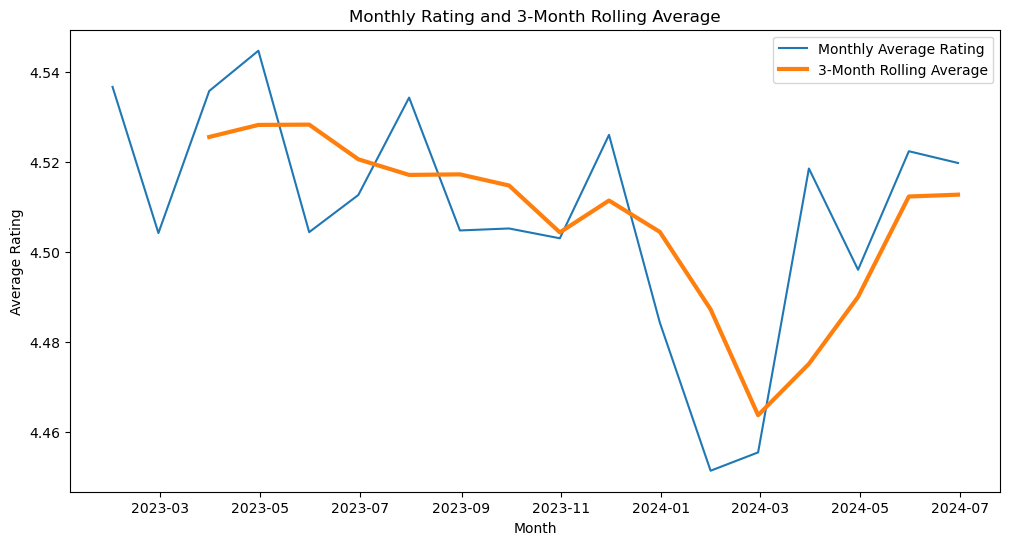

In [12]:
# Task 6 Answer: Customer satisfaction is slightly downward overall but becomes fairly stable after smoothing, with a small recovery toward the end. The raw monthly line looks more noisy and could make the trend appear less clear.

df["order_date"] = pd.to_datetime(df["order_date"])

monthly_rating = (
    df.set_index("order_date")["rating"]
    .resample("ME")
    .mean()
)

rolling_rating = monthly_rating.rolling(window=3).mean()

plt.figure(figsize=(12, 6))
plt.plot(
    monthly_rating,
    label="Monthly Average Rating"
)
plt.plot(
    rolling_rating,
    label="3-Month Rolling Average",
    linewidth=3
)
plt.xlabel("Month")
plt.ylabel("Average Rating")
plt.title("Monthly Rating and 3-Month Rolling Average")
plt.legend()
plt.show()




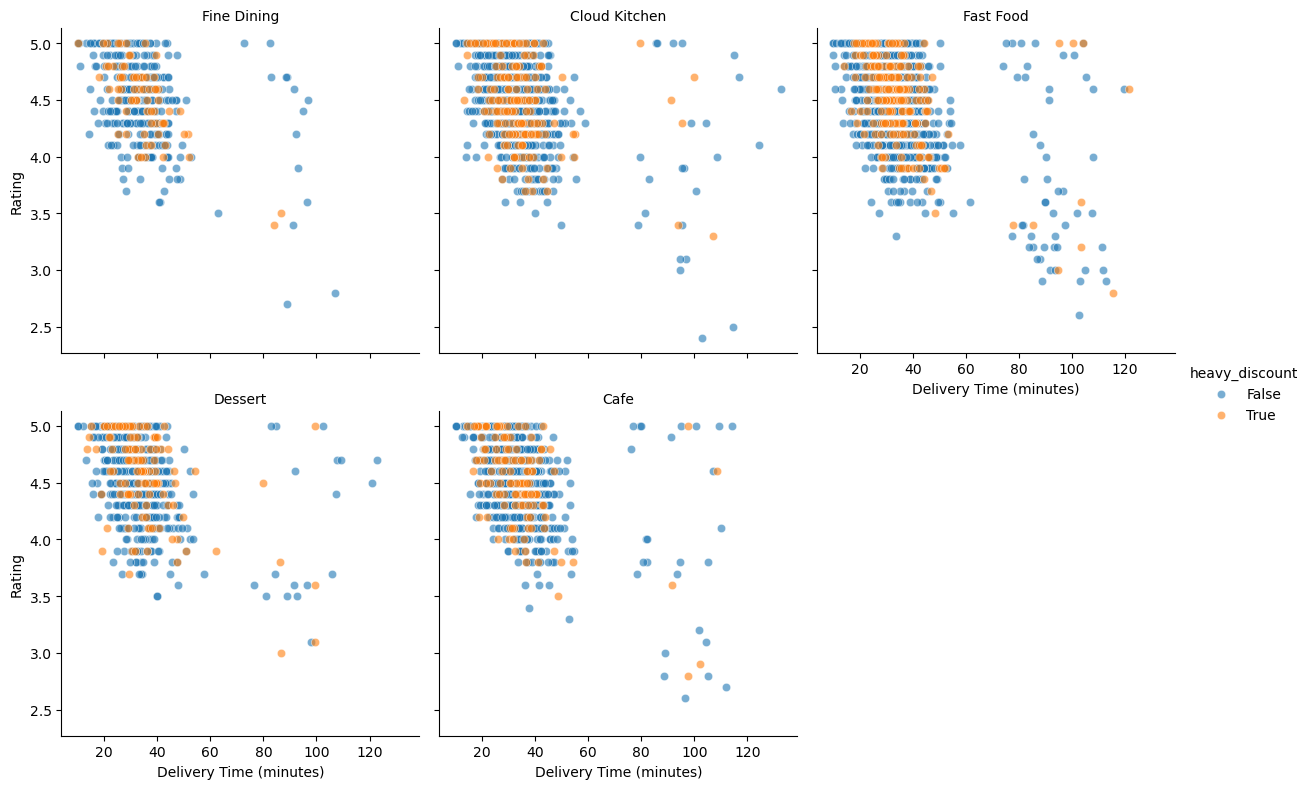

In [13]:

# Task 7 Answer: Cloud Kitchen shows the clearest difference: heavily discounted orders have a slightly higher average rating among slower deliveries, suggesting customers may be somewhat more forgiving of slow delivery when the discount is large.

df["heavy_discount"] = df["discount_percent"] > 20

g = sns.FacetGrid(
    df,
    col="restaurant_category",
    hue="heavy_discount",
    col_wrap=3,
    height=4
)

g.map_dataframe(
    sns.scatterplot,
    x="delivery_time_min",
    y="rating",
    alpha=0.6
)

g.add_legend()
g.set_axis_labels(
    "Delivery Time (minutes)",
    "Rating"
)
g.set_titles("{col_name}")
plt.show()



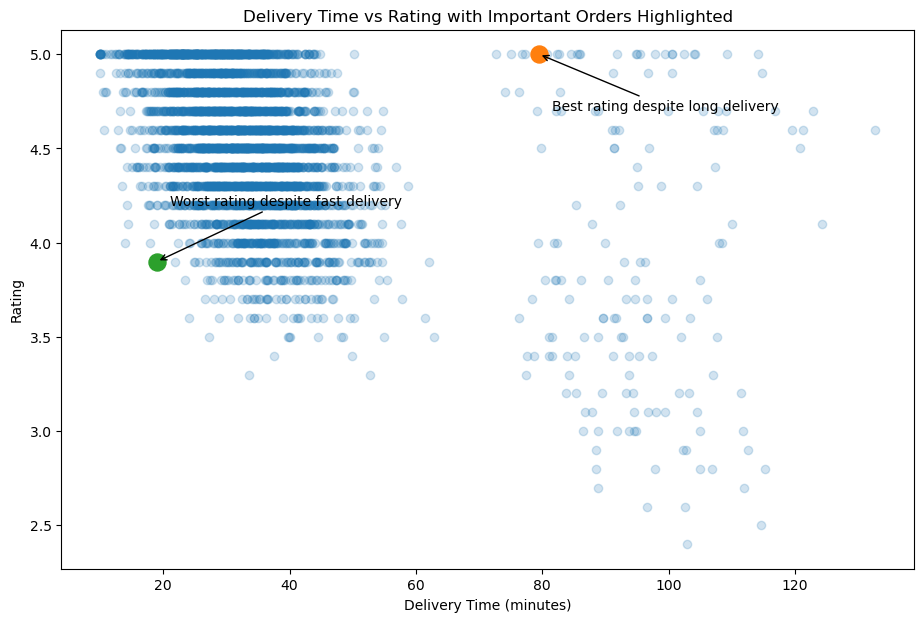

Best rating despite long delivery:
order_date             2023-01-21 00:00:00
city                                Lahore
restaurant_category                   Cafe
cuisine                         Sandwiches
order_value                          341.0
discount_percent                      10.5
delivery_time_min                     79.5
rating                                 5.0
profit_per_order                     -58.0
heavy_discount                       False
Name: 143, dtype: object

Worst rating despite fast delivery:
order_date             2024-02-11 00:00:00
city                             Islamabad
restaurant_category                Dessert
cuisine                              Cakes
order_value                          339.0
discount_percent                      38.2
delivery_time_min                     19.0
rating                                 3.9
profit_per_order                     -15.0
heavy_discount                        True
Name: 3114, dtype: object


In [14]:
# Task 8 Answer: Transparency is suitable because the repeated rating values create heavy overlap, and alpha makes dense regions visible. The unusual long-delivery order has a rating of 5.0 at 79.5 minutes, while the unusual fast-delivery order has a rating of 3.9 at 19 minutes.

long_delivery_limit = df["delivery_time_min"].quantile(0.95)
fast_delivery_limit = df["delivery_time_min"].quantile(0.05)

long_orders = df[
    df["delivery_time_min"] >= long_delivery_limit
]

fast_orders = df[
    df["delivery_time_min"] <= fast_delivery_limit
]

best_long = long_orders.loc[
    long_orders["rating"].idxmax()
]

worst_fast = fast_orders.loc[
    fast_orders["rating"].idxmin()
]

plt.figure(figsize=(11, 7))

plt.scatter(
    df["delivery_time_min"],
    df["rating"],
    alpha=0.2
)

plt.scatter(
    best_long["delivery_time_min"],
    best_long["rating"],
    s=150
)

plt.scatter(
    worst_fast["delivery_time_min"],
    worst_fast["rating"],
    s=150
)

plt.annotate(
    "Best rating despite long delivery",
    xy=(
        best_long["delivery_time_min"],
        best_long["rating"]
    ),
    xytext=(
        best_long["delivery_time_min"] + 2,
        best_long["rating"] - 0.3
    ),
    arrowprops=dict(arrowstyle="->")
)

plt.annotate(
    "Worst rating despite fast delivery",
    xy=(
        worst_fast["delivery_time_min"],
        worst_fast["rating"]
    ),
    xytext=(
        worst_fast["delivery_time_min"] + 2,
        worst_fast["rating"] + 0.3
    ),
    arrowprops=dict(arrowstyle="->")
)

plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Rating")
plt.title("Delivery Time vs Rating with Important Orders Highlighted")
plt.show()

print("Best rating despite long delivery:")
print(best_long)

print("\nWorst rating despite fast delivery:")
print(worst_fast)